# Imports + setup

In [1]:
!pip install torch_xla[tpu]~=2.9.0 -f https://storage.googleapis.com/libtpu-releases/index.html
!pip install lightning

Looking in links: https://storage.googleapis.com/libtpu-releases/index.html
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.8/149.8 MB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.0/846.0 kB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 54.1 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data

#import matplotlib.pyplot as plt
#from sklearn.preprocessing import MinMaxScaler

from torch.utils.data import DataLoader, Dataset
import math

In [3]:
import lightning as L
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
import torch_xla
import torch_xla.core.xla_model as xm

/usr/local/lib/python3.12/dist-packages/torch_xla/__init__.py:246: UserWarning: `tensorflow` can conflict with `torch-xla`. Prefer `tensorflow-cpu` when using PyTorch/XLA. To silence this warning, `pip uninstall -y tensorflow && pip install tensorflow-cpu`. If you are in a notebook environment such as Colab or Kaggle, restart your notebook runtime afterwards.
  warnings.warn(


# Transformer building blocks

## Multi-head attention

In [4]:
# d'ici @ https://docs.pytorch.org/tutorials/intermediate/transformer_building_blocks.html#multiheadattention

class MultiheadAttention(nn.Module):
    """
    Computes multi-head attention. Supports nested or padded tensors.

    Args:
        E_q (int): Size of embedding dim for query
        E_k (int): Size of embedding dim for key
        E_v (int): Size of embedding dim for value
        E_total (int): Total embedding dim of combined heads post input projection. Each head
            has dim E_total // nheads
        nheads (int): Number of heads
        dropout (float, optional): Dropout probability. Default: 0.0
        bias (bool, optional): Whether to add bias to input projection. Default: True
    """

    def __init__(
        self,
        E_q: int,
        E_k: int,
        E_v: int,
        E_total: int,
        nheads: int,
        dropout: float = 0.0,
        bias=True,
        device=None,
        dtype=None,
    ):
        factory_kwargs = {"device": device, "dtype": dtype}
        super().__init__()
        self.nheads = nheads
        self.dropout = dropout
        self._qkv_same_embed_dim = E_q == E_k and E_q == E_v
        if self._qkv_same_embed_dim:
            self.packed_proj = nn.Linear(E_q, E_total * 3, bias=bias, **factory_kwargs)
        else:
            self.q_proj = nn.Linear(E_q, E_total, bias=bias, **factory_kwargs)
            self.k_proj = nn.Linear(E_k, E_total, bias=bias, **factory_kwargs)
            self.v_proj = nn.Linear(E_v, E_total, bias=bias, **factory_kwargs)
        E_out = E_q
        self.out_proj = nn.Linear(E_total, E_out, bias=bias, **factory_kwargs)
        assert E_total % nheads == 0, "Embedding dim is not divisible by nheads"
        self.E_head = E_total // nheads
        self.bias = bias

    def forward(
        self,
        query: torch.Tensor,
        key: torch.Tensor,
        value: torch.Tensor,
        attn_mask=None,
        is_causal=False,
    ) -> torch.Tensor:
        """
        Forward pass; runs the following process:
            1. Apply input projection
            2. Split heads and prepare for SDPA
            3. Run SDPA
            4. Apply output projection

        Args:
            query (torch.Tensor): query of shape (``N``, ``L_q``, ``E_qk``)
            key (torch.Tensor): key of shape (``N``, ``L_kv``, ``E_qk``)
            value (torch.Tensor): value of shape (``N``, ``L_kv``, ``E_v``)
            attn_mask (torch.Tensor, optional): attention mask of shape (``N``, ``L_q``, ``L_kv``) to pass to SDPA. Default: None
            is_causal (bool, optional): Whether to apply causal mask. Default: False

        Returns:
            attn_output (torch.Tensor): output of shape (N, L_t, E_q)
        """
        # Step 1. Apply input projection
        if self._qkv_same_embed_dim:
            if query is key and key is value:
                result = self.packed_proj(query)
                query, key, value = torch.chunk(result, 3, dim=-1)
            else:
                q_weight, k_weight, v_weight = torch.chunk(
                    self.packed_proj.weight, 3, dim=0
                )
                if self.bias:
                    q_bias, k_bias, v_bias = torch.chunk(
                        self.packed_proj.bias, 3, dim=0
                    )
                else:
                    q_bias, k_bias, v_bias = None, None, None
                query, key, value = (
                    F.linear(query, q_weight, q_bias),
                    F.linear(key, k_weight, k_bias),
                    F.linear(value, v_weight, v_bias),
                )

        else:
            query = self.q_proj(query)
            key = self.k_proj(key)
            value = self.v_proj(value)

        # Step 2. Split heads and prepare for SDPA
        # reshape query, key, value to separate by head
        # (N, L_t, E_total) -> (N, L_t, nheads, E_head) -> (N, nheads, L_t, E_head)
        query = query.unflatten(-1, [self.nheads, self.E_head]).transpose(1, 2)
        # (N, L_s, E_total) -> (N, L_s, nheads, E_head) -> (N, nheads, L_s, E_head)
        key = key.unflatten(-1, [self.nheads, self.E_head]).transpose(1, 2)
        # (N, L_s, E_total) -> (N, L_s, nheads, E_head) -> (N, nheads, L_s, E_head)
        value = value.unflatten(-1, [self.nheads, self.E_head]).transpose(1, 2)

        # Step 3. Run SDPA
        # (N, nheads, L_t, E_head)
        attn_output = F.scaled_dot_product_attention(
            query, key, value, dropout_p=self.dropout, is_causal=is_causal
        )
        # (N, nheads, L_t, E_head) -> (N, L_t, nheads, E_head) -> (N, L_t, E_total)
        attn_output = attn_output.transpose(1, 2).flatten(-2)

        # Step 4. Apply output projection
        # (N, L_t, E_total) -> (N, L_t, E_out)
        attn_output = self.out_proj(attn_output)

        return attn_output

## Positional encoding

In [5]:
# Sinusoidal positional encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        """Positional Encoding.

        Args:
            d_model: Hidden dimensionality of the input.
            max_len: Maximum length of a sequence to expect.

        """
        super().__init__()

        # Create matrix of [SeqLen, HiddenDim] representing the positional encoding for max_len inputs
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)

        # register_buffer => Tensor which is not a parameter, but should be part of the modules state.
        # Used for tensors that need to be on the same device as the module.
        # persistent=False tells PyTorch to not add the buffer to the state dict (e.g. when we save the model)
        self.register_buffer("pe", pe, persistent=False)

    def forward(self, x):
        x = x + self.pe[:, : x.size(1),:]
        return x

## Decoder block (no encoder)

In [6]:
class DecoderBlock(nn.Module):
    def __init__(self, tgt_dim, num_heads, dim_feedforward, dropout=0.1):
        """DecoderBlock.

        Args:
            tgt_dim: Dimensionality of the decoder input
            num_heads: Number of heads to use in the attention block
            dim_feedforward: Dimensionality of the hidden layer in the MLP
            dropout: Dropout probability to use in the dropout layers

        """
        super().__init__()

        # Masked self-attention layer
        self.self_attn = MultiheadAttention(tgt_dim, tgt_dim, tgt_dim,
                                            tgt_dim, num_heads)

        # Two-layer MLP
        self.linear_net = nn.Sequential(
            nn.Linear(tgt_dim, dim_feedforward),
            nn.Dropout(dropout),
            nn.ReLU(inplace=True),
            nn.Linear(dim_feedforward, tgt_dim),
        )

        # Layers to apply in between the main layers
        self.norm1 = nn.LayerNorm(tgt_dim)
        self.norm2 = nn.LayerNorm(tgt_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt, mask=None):
        batch_size, seq_length, embed_dim = tgt.size()

        # Masked self-attention part
        attn_out = self.self_attn(tgt, tgt, tgt, is_causal=True)
        tgt = tgt + self.dropout(attn_out)
        tgt = self.norm1(tgt)

        # MLP part
        linear_out = self.linear_net(tgt)
        tgt = tgt + self.dropout(linear_out)
        tgt = self.norm2(tgt)

        return tgt

class TransformerDecoder(nn.Module):
    def __init__(self, num_layers, **block_args):
        super().__init__()
        self.layers = nn.ModuleList([DecoderBlock(**block_args) for _ in range(num_layers)])

    def forward(self, tgt, mask=None):
        for layer in self.layers:
            x = layer(tgt, mask=mask)
        return x

    def get_attention_maps(self, tgt, mask=None):
        attention_maps = []
        for layer in self.layers:
            _, attn_map = layer.attn(tgt, mask=mask, return_attention=True)
            attention_maps.append(attn_map)
            tgt = layer(tgt)
        return attention_maps

## Scheduler

I don't know if I need the next bit or if I can just use Pytorch Lightning's built-in scheduler.

In [7]:
import torch.optim as optim
import numpy as np

In [8]:
class CosineWarmupScheduler(optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, warmup, max_iters):
        self.warmup = warmup
        self.max_num_iters = max_iters
        super().__init__(optimizer)

    def get_lr(self):
        lr_factor = self.get_lr_factor(epoch=self.last_epoch)
        return [base_lr * lr_factor for base_lr in self.base_lrs]

    def get_lr_factor(self, epoch):
        lr_factor = 0.5 * (1 + np.cos(np.pi * epoch / self.max_num_iters))
        if epoch <= self.warmup:
            lr_factor *= epoch * 1.0 / self.warmup
        return lr_factor

# Transformer class

In [9]:
#from sklearn.metrics import f1_score
from torchmetrics.classification import BinaryF1Score, BinaryConfusionMatrix

In [10]:
class TransformerQEDec(L.LightningModule):
    def __init__(
        self,
        input_dim,
        model_dim,
        num_classes,
        num_heads,
        num_layers,
        lr,
        warmup,
        max_iters,
        dropout=0.1,
        input_dropout=0.1,
    ):
        """TransformerQEDec.

        Args:
            input_dim: Hidden dimensionality of the input
            model_dim: Hidden dimensionality to use inside the Transformer
            num_classes: Number of classes to predict per sequence element
            num_heads: Number of heads to use in the Multi-Head Attention blocks
            num_layers: Number of decoder blocks to use.
            lr: Learning rate in the optimizer
            warmup: Number of warmup steps. Usually between 50 and 500
            max_iters: Number of maximum iterations the model is trained for. This is needed for the CosineWarmup scheduler
            dropout: Dropout to apply inside the model
            input_dropout: Dropout to apply on the input features

        """
        super().__init__()
        self.save_hyperparameters()
        self._create_model()

    def _create_model(self):
        # Input dim -> Model dim
        self.input_net = nn.Sequential(
            nn.Dropout(self.hparams.input_dropout),
            nn.Linear(self.hparams.input_dim, self.hparams.model_dim)
        )
        # Positional encoding for sequences
        self.positional_encoding = PositionalEncoding(d_model=self.hparams.model_dim)

        # Decoder
        self.decoder = TransformerDecoder(
            num_layers=self.hparams.num_layers,
            tgt_dim=self.hparams.model_dim,
            num_heads=self.hparams.num_heads,
            dim_feedforward=2 * self.hparams.model_dim,
        )

        # Output classifier
        self.output_net = nn.Sequential(
            nn.Linear(self.hparams.model_dim, self.hparams.model_dim),
            nn.LayerNorm(self.hparams.model_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(self.hparams.dropout),
            nn.Linear(self.hparams.model_dim, self.hparams.num_classes),
        )

    def forward(self, x, mask=None, add_positional_encoding=True):
        """
        Args:
            x: Input features of shape [Batch, SeqLen, input_dim]
            mask: Mask to apply on the attention outputs (optional)
            add_positional_encoding: If True, we add the positional encoding to the input.
                                      Might not be desired for some tasks.
        """
        x = self.input_net(x)
        if add_positional_encoding:
            x = self.positional_encoding(x)
        x = self.decoder(x, mask=mask)
        x = self.output_net(x)
        return x

    @torch.no_grad()
    def get_attention_maps(self, x, mask=None, add_positional_encoding=True):
        """Function for extracting the attention matrices of the whole Transformer
        for a single batch.

        Input arguments same as the forward pass.

        """
        src = self.input_net(x)
        if add_positional_encoding:
            x = self.positional_encoding(x)
        attention_maps = self.decoder.get_attention_maps(x, mask=mask)

        return attention_maps

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=self.hparams.lr)

        # We don't return the lr scheduler because we need to apply it per iteration, not per epoch
        self.lr_scheduler = CosineWarmupScheduler(
            optimizer, warmup=self.hparams.warmup, max_iters=self.hparams.max_iters
        )
        return optimizer

    def optimizer_step(self, *args, **kwargs):
        super().optimizer_step(*args, **kwargs)
        self.lr_scheduler.step()  # Step per iteration

    def training_step(self, batch, batch_idx):
        inputs, obs = batch
        # targets will be of shape [Batch, SeqLen] with class indices (0 or 1)
        targets = torch.cat((inputs[:,1:],obs),axis=1)
        # outputs will be of shape [Batch, SeqLen, num_classes]
        outputs = self(inputs.unsqueeze(-1))

        # Reshape outputs to [Batch * SeqLen, num_classes]
        # logits = outputs.view(-1, outputs.shape[-1])
        # keep only last output per sequence
        logits = outputs[:,-1,:]
        # Reshape targets to [Batch * SeqLen] and convert to long for class indices
        class_targets = obs.view(-1).long()

        #loss = F.cross_entropy(logits, class_targets)
        loss = F.cross_entropy(logits, class_targets, weight=torch.tensor([0.06,0.94],
                                                                          device=self.device))
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        inputs, obs = batch
        # targets will be of shape [Batch, SeqLen] with class indices (0 or 1)
        targets = torch.cat((inputs[:,1:],obs),axis=1)

        # outputs will be of shape [Batch * SeqLen, num_classes]
        outputs = self(inputs.unsqueeze(-1))

        # Reshape outputs to [Batch * SeqLen, num_classes]
        # logits = outputs.view(-1, outputs.shape[-1])
        # keep only last output per sequence
        logits = outputs[:,-1,:]
        # Reshape targets and convert to long for class indices
        class_targets = obs.view(-1).long()

        #loss = F.cross_entropy(logits, class_targets)
        loss = F.cross_entropy(logits, class_targets, weight=torch.tensor([0.06,0.94],
                                                                          device=self.device))
        self.log("valid_loss", loss, prog_bar=True)

    def test_step(self, batch, batch_idx):
        inputs, obs = batch
        # targets will be of shape [Batch, SeqLen] with class indices (0 or 1)
        targets = torch.cat((inputs[:,1:],obs),axis=1)
        # outputs will be of shape [Batch, SeqLen, num_classes]
        outputs = self(inputs.unsqueeze(-1))

        # Reshape outputs to [Batch * SeqLen, num_classes]
        # logits = outputs.view(-1, outputs.shape[-1])
        # keep only last output per sequence
        logits = outputs[:,-1,:]
        # Reshape targets to [Batch * SeqLen] and convert to long for class indices
        #class_targets = targets.view(-1).long()
        class_targets = obs.view(-1).long()

        # Initialize metrics and move it to the correct device
        f1_metric = BinaryF1Score(threshold=0.8).to(self.device)
        # loss = F.cross_entropy(logits, class_targets)
        loss = F.cross_entropy(logits, class_targets, weight=torch.tensor([0.06,0.94],
                                                                          device=self.device))
        # for n=3: 0.06, 0.94; for n=5: 0.084, 0.916; for n=11: 0.1, 0.9; (n=11, p=0.07) 0.03, 0.97
        #probs = F.softmax(logits, dim=1)
        #classifications = torch.where(probs[:,0] > 0.9, 0, 1)

        f1 = f1_metric(logits.argmax(axis=1), class_targets)
        #self.log("test_loss", loss, prog_bar=True)
        #self.log("f1_score", f1, prog_bar=True)

        return {'test_loss': loss, 'f1_score':f1}

# Data loader / handler

In [15]:
class SynObsData(Dataset):
    def __init__(self, set_size=75000000, seq_length=24,
                 files=('drive/MyDrive/stimdat1/syndrome3.npb',
                        'drive/MyDrive/stimdat1/obs3.npb')):
      def load_bool_array(path, shape):
        """
        Load packed boolean array using memory mapping.
        """
        rows, cols = shape
        packed_cols = (cols + 7) // 8
        mm = np.memmap(path,
            dtype=np.uint8,
            mode="r",
            shape=(rows, packed_cols),)
        arr = np.unpackbits(mm, axis=1)
        return arr[:, :cols].astype(bool, copy=False)

      self.syndrome = load_bool_array(files[0], (set_size, seq_length))
      self.obs = load_bool_array(files[1], (set_size, 1))

    def __len__(self):
        return len(self.obs)

    def __getitem__(self, index):
        return (
            torch.tensor(self.syndrome[index], dtype=torch.float),
            torch.tensor(self.obs[index], dtype=torch.float),
        )

In [16]:
# Create DataLoader
dataset = SynObsData()

# train / test split
tv_set_size = int(len(dataset) * 0.9)
test_set_size = len(dataset) - tv_set_size
seed = torch.Generator().manual_seed(427)
train_set, test_set = data.random_split(dataset, [tv_set_size, test_set_size], generator=seed)

# train / validation split
# use 20% of training data for validation
train_set_size = int(len(train_set) * 0.8)
valid_set_size = len(train_set) - train_set_size
seed = torch.Generator().manual_seed(427)
train_set, valid_set = data.random_split(train_set, [train_set_size, valid_set_size], generator=seed)

train_loader = DataLoader(train_set, shuffle=True, batch_size=128) #, num_workers=12)
valid_loader = DataLoader(valid_set, batch_size=128) #, num_workers=12)
test_loader = DataLoader(test_set, batch_size=1024) #, num_workers=12)

# Main training code

In [11]:
# Initialize model
model = TransformerQEDec(input_dim=1, model_dim=36, num_classes=2,
                         num_heads=6, num_layers=6,
                         lr=1E-5, warmup=200, max_iters=1000)


In [12]:
# Use iff training on non-T4 G/TPUs with tensor cores
torch.backends.fp32_precision = "ieee"
torch.backends.cuda.matmul.fp32_precision = "ieee"
torch.backends.cudnn.fp32_precision = "ieee"
torch.backends.cudnn.conv.fp32_precision = "tf32"
torch.backends.cudnn.rnn.fp32_precision = "tf32"

In [13]:
from lightning.pytorch.callbacks import ModelCheckpoint

In [ ]:
# Train model with both splits
early_stop_callback = EarlyStopping(monitor="valid_loss", min_delta=0.001, patience=3,
                                verbose=True, mode="min")
cp_callback = ModelCheckpoint(
    dirpath='drive/MyDrive/stimdat1',
)
trainer = L.Trainer(callbacks=[early_stop_callback, cp_callback], max_epochs=100,
                    accelerator="cuda", devices="auto")
#trainer.fit(model, train_loader, valid_loader)
trainer.fit(model, train_loader, valid_loader,
             ckpt_path="drive/MyDrive/stimdat1/epoch=22-step=9703125.ckpt",
             #ckpt_path="lightning_logs/version_1/checkpoints/epoch=0-step=84375.ckpt",
             weights_only = False)

# Testing

In [13]:
model = TransformerQEDec.load_from_checkpoint("drive/MyDrive/stimdat1/epoch=22-step=9703125.ckpt", weights_only = False)

In [18]:
batch = next(iter(test_loader))
inputs, obs = batch
inputs = inputs.to(model.device)  # Move inputs to the model's device (GPU)
obs = obs.to(model.device)        # Move observations to the model's device (GPU)
metrics = model.test_step((inputs, obs), 0)
print(metrics)

{'test_loss': tensor(0.4759, grad_fn=<NllLossBackward0>), 'f1_score': tensor(0.2507)}


In [19]:
outputs = model.forward(inputs.unsqueeze(-1))
logits = outputs[:,-1,:]
class_targets = obs.view(-1).long()
pt = F.softmax(logits,dim=1)[:,1].detach().cpu().numpy()

In [23]:
[len([x for x in pt if x > threshold]) for threshold in [0.5, 0.6, 0.7, 0.75, 0.78, 0.8]]

[319, 242, 151, 105, 77, 59]

In [27]:
y = [(i, pt[i]) for i in range(len(class_targets)) if class_targets[i] == 1]
len(y), len([x for x in y if x[1]>0.7])

(58, 30)

In [28]:
import matplotlib.pyplot as plt

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: xlabel='Predicted class', ylabel='True class'>)

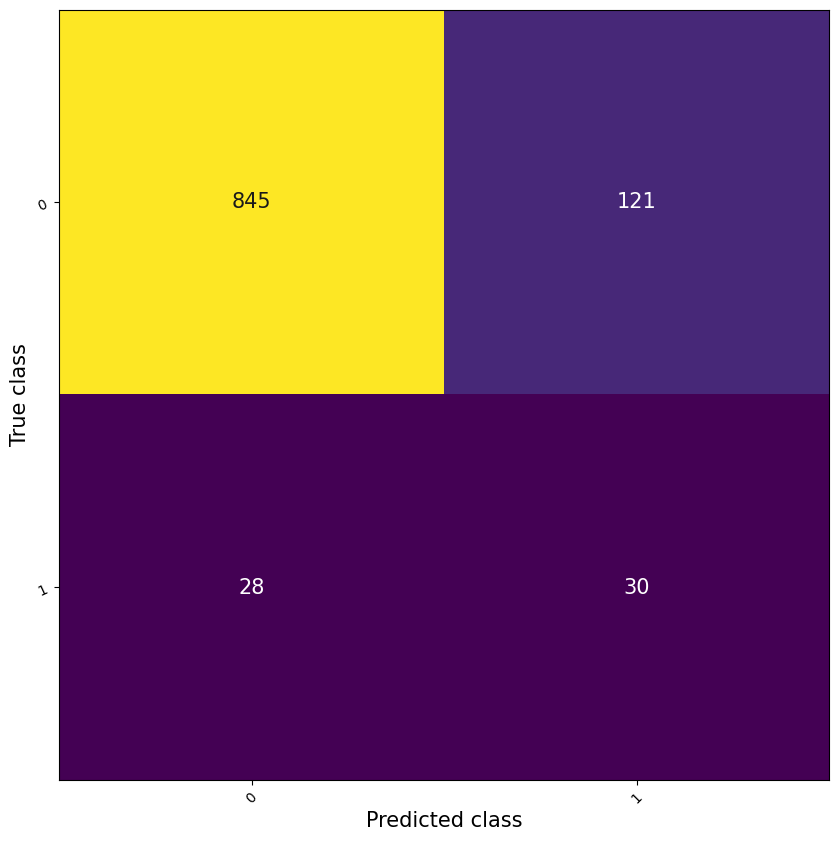

In [45]:
# Initialize metrics and move it to the correct device
f1_metric = BinaryF1Score().to(model.device)
confuse_matrix = BinaryConfusionMatrix().to(model.device)

probs = F.softmax(logits, dim=1)
classifications = torch.where(probs[:,1] > 0.7, 1, 0)

f1 = f1_metric(classifications, class_targets)
cm = confuse_matrix(classifications, class_targets)

fig, ax = plt.subplots(figsize=(10, 10))
confuse_matrix.plot(ax=ax, labels=[0, 1])

In [48]:
f1

tensor(0.2871)

In [ ]:
from google.colab import runtime
runtime.unassign()